# Week 1 — CICIDS2017 EDA

Goal: load the CICIDS2017 CSVs, understand class distribution, check for data quality issues (NaN/Inf, duplicates), and get a feel for the feature space before preprocessing.

Place the downloaded CSVs (from the `MachineLearningCSV.zip` on Kaggle, or UNB's official site) into `data/raw/` before running this.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

sns.set_theme(style="whitegrid")
DATA_DIR = "../data/raw"

## 1. Load all CSVs

CICIDS2017 ships as one CSV per day (Monday–Friday), each covering different attack scenarios. We load and concatenate them all.

In [2]:
csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))
print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(" -", os.path.basename(f))

Found 8 CSV files:
 - Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
 - Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
 - Friday-WorkingHours-Morning.pcap_ISCX.csv
 - Monday-WorkingHours.pcap_ISCX.csv
 - Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
 - Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
 - Tuesday-WorkingHours.pcap_ISCX.csv
 - Wednesday-workingHours.pcap_ISCX.csv


In [3]:
dfs = []
for f in csv_files:
    df_part = pd.read_csv(f, low_memory=False)
    df_part.columns = df_part.columns.str.strip()  # CICIDS2017 columns have leading spaces
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)
print("Combined shape:", df.shape)
df.head()

Combined shape: (2830743, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


## 2. Class distribution

Check how imbalanced the labels are — this will drive our preprocessing decisions in Week 2 (SMOTE, class weighting, etc.).

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack � Brute Force         1507
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


C:\Users\kimay\AppData\Local\Temp\ipykernel_42712\1792248249.py:9: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\kimay\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65533 (\N{REPLACEMENT CHARACTER}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


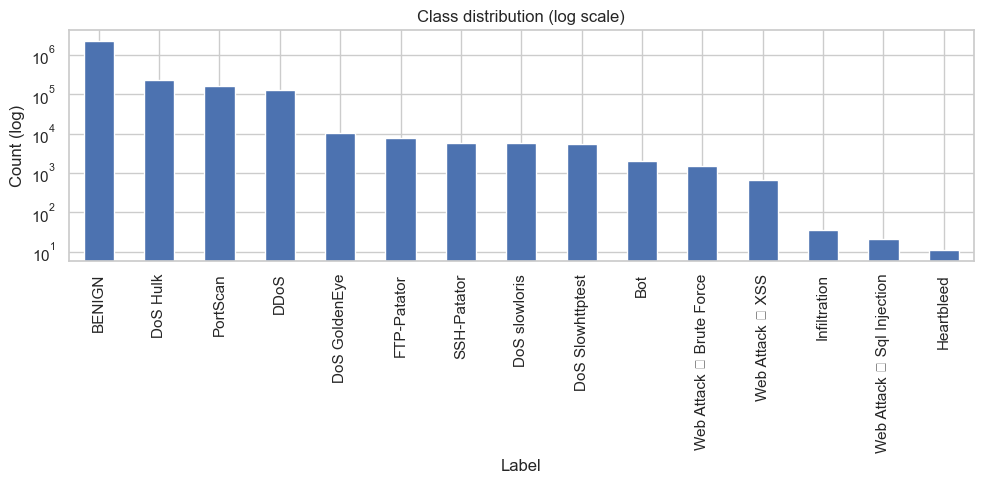

In [4]:
label_col = "Label"  # confirm this matches your CSV's actual column name
print(df[label_col].value_counts())

plt.figure(figsize=(10, 5))
df[label_col].value_counts().plot(kind="bar")
plt.title("Class distribution (log scale)")
plt.yscale("log")
plt.ylabel("Count (log)")
plt.tight_layout()
plt.show()

## 3. Data quality checks

CICIDS2017 is known to have `Infinity` and `NaN` values in a few columns (e.g. Flow Bytes/s, Flow Packets/s from division by zero). Check before deciding how to handle them in Week 2.

In [5]:
print("Shape before cleanup:", df.shape)

n_inf = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print("Total infinite values:", n_inf)

n_nan = df.isna().sum().sum()
print("Total NaN values:", n_nan)

n_dupes = df.duplicated().sum()
print("Duplicate rows:", n_dupes)

Shape before cleanup: (2830743, 79)
Total infinite values: 4376
Total NaN values: 1358
Duplicate rows: 308381


## 4. Feature overview

Quick look at feature types and a few key distributions (flow duration, packet counts) split by benign vs attack.

In [6]:
df.dtypes.value_counts()

int64      54
float64    24
object      1
Name: count, dtype: int64

In [7]:
df.describe().T.head(20)

C:\Users\kimay\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\kimay\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,count,mean,std,min,25%,50%,75%,max
Destination Port,2830743.0,8.071483e+03,1.828363e+04,0.0,53.000000,80.000000,4.430000e+02,6.553500e+04
Flow Duration,2830743.0,1.478566e+07,3.365374e+07,-13.0,155.000000,31316.000000,3.204828e+06,1.200000e+08
Total Fwd Packets,2830743.0,9.361160e+00,7.496728e+02,1.0,2.000000,2.000000,5.000000e+00,2.197590e+05
Total Backward Packets,2830743.0,1.039377e+01,9.973883e+02,0.0,1.000000,2.000000,4.000000e+00,2.919220e+05
Total Length of Fwd Packets,2830743.0,5.493024e+02,9.993589e+03,0.0,12.000000,62.000000,1.870000e+02,1.290000e+07
Total Length of Bwd Packets,2830743.0,1.616264e+04,2.263088e+06,0.0,0.000000,123.000000,4.820000e+02,6.554530e+08
Fwd Packet Length Max,2830743.0,2.075999e+02,7.171848e+02,0.0,6.000000,37.000000,8.100000e+01,2.482000e+04
Fwd Packet Length Min,2830743.0,1.871366e+01,6.033935e+01,0.0,0.000000,2.000000,3.600000e+01,2.325000e+03
Fwd Packet Length Mean,2830743.0,5.820194e+01,1.860912e+02,0.0,6.000000,34.000000,5.000000e+01,5.940857e+03
Fwd Packet Length Std,2830743.0,6.891013e+01,2.811871e+02,0.0,0.000000,0.000000,2.616295e+01,7.125597e+03


## Next steps (Week 2)

- Handle Inf/NaN rows (drop or impute)
- Drop duplicate rows
- Encode/drop non-numeric columns (if any besides Label)
- Decide train/test split strategy (stratified, given class imbalance)
- Address class imbalance (SMOTE vs class_weight)
- Train baseline Random Forest